# Weightlifting Injury Detection

**Miriam Koppe, Ramona Koksa, Sahin Oyman, Sandra Vogel, Tim von Gunten**  
BINA FS26  
Fernfachhochschule Schweiz / Berner Fachhochschule

# Datensammlung
Im folgenden Abschnitt werden die strukturierten Daten gesammelt, bereinigt und modelliert. Weitere Details sind der beigefügten Dokumentation zu entnehmen.

In [39]:
import numpy as np
import pandas as pd
import seaborn as sns
import sqlite3

from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.metrics import auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [3]:
# Google Drive unter dem Pfad '/content/drive' wird eingebunden um später die Daten zu lesen
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Definieren des vollständigen Pfads zur Datei
file_path = '/content/drive/MyDrive/BINA/'

# CSV laden
df1 = pd.read_csv(file_path + "WL_injuries_MasterAthletes.csv")

# Excel laden
df2 = pd.read_excel(file_path + "High_Accuracy_Sport_Injury_Dataset.xlsx")

# Daten untersuchen
print("Dataset 1 Columns:")
print(df1.columns)
print("\nDataset 1 Info:")
print(df1.info())

print("\nDataset 2 Columns:")
print(df2.columns)
print("\nDataset 2 Info:")
print(df2.info())

Dataset 1 Columns:
Index(['id', 'sex', 'age', 'agegrp3', 'age_start', 'yrs_experience',
       'shoulder', 'knees', 'back', 'wrist', 'hips', 'OA', 'train_days',
       'train_session', 'train_warm', 'train_lift', 'train_strength',
       'train_supp', 'train_cool', 'pcoach', 'premote', 'pown', 'nutrition',
       'pa_power', 'pa_body', 'pa_cf', 'pa_ball', 'pa_fit', 'pa_endure',
       'pa_track', 'pa_ma', 'pa_yoga', 'sport0_power', 'sport0_body',
       'sport0_cf', 'sport0_ball', 'sport0_fit', 'sport0_endure',
       'sport0_track', 'sport0_ma', 'sport0_yoga', 'sport0_gym',
       'sport0_strength', 'sport0_impact'],
      dtype='object')

Dataset 1 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 44 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               976 non-null    int64 
 1   sex              976 non-null    object
 2   age              976 non-null    int64 
 3   

### Rohdaten in Sqlite Datenbank laden

In [5]:
conn = sqlite3.connect("injury_analysis.db")

df1.to_sql("wl_raw", conn, if_exists="replace", index=False)
df2.to_sql("sport_raw", conn, if_exists="replace", index=False)

df1 = pd.read_sql("SELECT * FROM wl_raw", conn)
df2 = pd.read_sql("SELECT * FROM sport_raw", conn)

### Targets erstellen

In [6]:
# Injury aus mehreren Spalten erkennen und harmonisieren
df1["injury"] = (df1[["shoulder", "knees", "back", "wrist"]].sum(axis=1) > 0).astype(int)

# Injury direkt aus dem zweiten Datenset übernehmen, da schon vorhanden
df2["injury"] = df2["Injury_Risk"]

### Spalten vereinheitlichen

In [7]:
df2_clean = df2.rename(columns={
    "Age": "age",
    "Gender": "gender",
    "Training_Frequency": "training_frequency",
    "Training_Duration": "training_duration",
    "Warmup_Time": "warmup_time",
    "Training_Intensity": "training_intensity",
    "Injury_History": "previous_injury",
    "Sleep_Hours": "sleep_hours",
    "Flexibility_Score": "flexibility_score",
    "Muscle_Asymmetry": "muscle_asymmetry",
    "Recovery_Time": "recovery_time",
    "Stress_Level": "stress_level"
})

# Gender fix (0/1 → m/f)
df2_clean["gender"] = df2_clean["gender"].map({0: "m", 1: "f"})

### Neues Schema modellieren

In [8]:
df1_clean = pd.DataFrame()

df1_clean["age"] = df1["age"]
df1_clean["gender"] = df1["sex"].str.lower()

df1_clean["training_frequency"] = df1["train_days"]
df1_clean["training_duration"] = df1["train_session"]
df1_clean["warmup_time"] = df1["train_warm"]

df1_clean["training_intensity"] = df1["train_lift"]
df1_clean["previous_injury"] = df1["OA"]

df1_clean["injury"] = df1["injury"]

# fehlende Features ergänzen
df1_clean["sleep_hours"] = np.nan
df1_clean["flexibility_score"] = np.nan
df1_clean["muscle_asymmetry"] = np.nan
df1_clean["recovery_time"] = np.nan
df1_clean["stress_level"] = np.nan

required_columns = df1_clean.columns

for col in required_columns:
    if col not in df2_clean.columns:
        df2_clean[col] = None

df2_clean = df2_clean[required_columns]

df_all = pd.concat([df1_clean, df2_clean], ignore_index=True)

# Datentypen bereinigen
df_all.columns = df_all.columns.str.lower().str.strip()

# Ergebnis prüfen
df_all

,age,gender,training_frequency,training_duration,warmup_time,training_intensity,previous_injury,injury,sleep_hours,flexibility_score,muscle_asymmetry,recovery_time,stress_level
0,42,m,3,1,2,4.0,1,1,NaN,NaN,NaN,NaN,NaN
1,54,m,3,2,1,5.0,1,1,NaN,NaN,NaN,NaN,NaN
2,40,m,5,4,2,4.0,1,1,NaN,NaN,NaN,NaN,NaN
3,37,m,4,3,2,3.0,1,1,NaN,NaN,NaN,NaN,NaN
4,48,f,3,2,1,4.0,1,0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1571,35,m,1,110,20,5.1,0,0,6.9,50.6,1.6,92.0,10.0
1572,34,m,5,64,4,6.7,0,0,7.3,59.9,4.2,30.0,2.0
1573,28,m,5,101,13,6.4,0,0,7.5,53.6,6.7,47.0,8.0
1574,33,m,2,89,16,4.9,2,1,7.9,54.7,2.1,95.0,8.0


### Fehlende Features mittels KNN erweitern
Durch das Zusammenführen der Datensätze entstehen fehlende Werte (Missing Values, NaN),
da nicht alle Features in beiden Datensätzen vorhanden sind. Diese fehlenden Werte wurden mithilfe der K-Nearest Neighbors (KNN) Imputation geschätzt.


In [9]:
# 1. Features definieren
features_to_impute = [
    "sleep_hours",
    "flexibility_score",
    "muscle_asymmetry",
    "recovery_time",
    "previous_injury",
    "stress_level",
    "training_intensity"
]

# 2. Datentypen sicherstellen
df_all[features_to_impute] = df_all[features_to_impute].apply(
    pd.to_numeric, errors="coerce"
)

# 3. Imputation flag
mask = df_all["sleep_hours"].isna()
df_all["imputed_flag"] = mask.astype(int)

# 4. Nur relevante Spalten imputen
imputer = KNNImputer(n_neighbors=5)

df_all[features_to_impute] = imputer.fit_transform(df_all[features_to_impute])

# 5. Check
print(df_all[features_to_impute].isna().sum())

# 6. Statistik
df_all.describe()

sleep_hours           0
flexibility_score     0
muscle_asymmetry      0
recovery_time         0
previous_injury       0
stress_level          0
training_intensity    0
dtype: int64


,age,training_frequency,training_duration,warmup_time,training_intensity,previous_injury,injury,sleep_hours,flexibility_score,muscle_asymmetry,recovery_time,stress_level,imputed_flag
count,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000,1576.000000
mean,42.072335,3.676396,33.369924,4.696066,4.368084,0.525381,0.501269,7.232919,61.091497,5.211231,76.300254,5.834010,0.619289
std,13.971303,1.375745,41.248679,5.656372,1.641440,0.662360,0.500157,0.549342,7.624729,1.953746,17.723023,1.998211,0.485716
min,18.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,5.000000,30.500000,0.000000,30.000000,1.000000,0.000000
25%,32.000000,3.000000,3.000000,1.000000,3.000000,0.000000,0.000000,6.860000,55.300000,3.920000,69.400000,4.800000,0.000000
50%,40.000000,4.000000,3.000000,2.000000,4.000000,0.000000,1.000000,7.200000,62.500000,5.300000,77.000000,5.800000,1.000000
75%,52.000000,5.000000,72.000000,7.000000,5.000000,1.000000,1.000000,7.560000,65.020000,5.900000,82.250000,7.000000,1.000000
max,88.000000,7.000000,120.000000,20.000000,10.000000,3.000000,1.000000,9.500000,94.600000,14.400000,119.000000,10.000000,1.000000


### Daten in Sqlite Datenbank laden
Damit später eine bessere Daten Analyse erstellt werden kann, werden die Daten in eine Sqlite Datenbank geladen.

In [10]:
# Harmonisierte Daten laden
df_all.to_sql("athlete_data", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM athlete_data LIMIT 5;", conn)

,age,gender,training_frequency,training_duration,warmup_time,training_intensity,previous_injury,injury,sleep_hours,flexibility_score,muscle_asymmetry,recovery_time,stress_level,imputed_flag
0,42,m,3,1,2,4.0,1.0,1,6.86,51.38,5.68,81.8,4.8,1
1,54,m,3,2,1,5.0,1.0,1,6.78,64.42,7.16,70.6,5.4,1
2,40,m,5,4,2,4.0,1.0,1,6.86,51.38,5.68,81.8,4.8,1
3,37,m,4,3,2,3.0,1.0,1,7.14,64.02,3.92,77.0,5.0,1
4,48,f,3,2,1,4.0,1.0,0,6.86,51.38,5.68,81.8,4.8,1


In [11]:
pd.read_sql("""
SELECT gender, AVG(injury) as injury_rate
FROM athlete_data
GROUP BY gender
""", conn)

,gender,injury_rate
0,f,0.452880
1,m,0.546798


# Datenanalyse

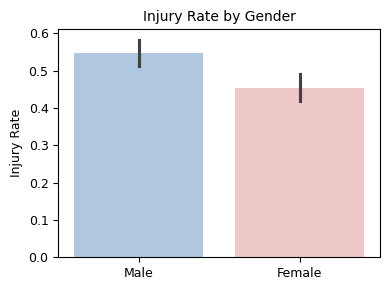

In [14]:
plt.figure(figsize=(4, 3))

palette_gender = {"m": "#A7C7E7", "f": "#F4C2C2"}

sns.barplot(
    data=df_all,
    x="gender",
    y="injury",
    order=["m", "f"],
    hue="gender",
    palette=palette_gender,
    legend=False
)

plt.title("Injury Rate by Gender", fontsize=10)
plt.xlabel("", fontsize=9)
plt.ylabel("Injury Rate", fontsize=9)

plt.xticks([0, 1], ["Male", "Female"], fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.show()

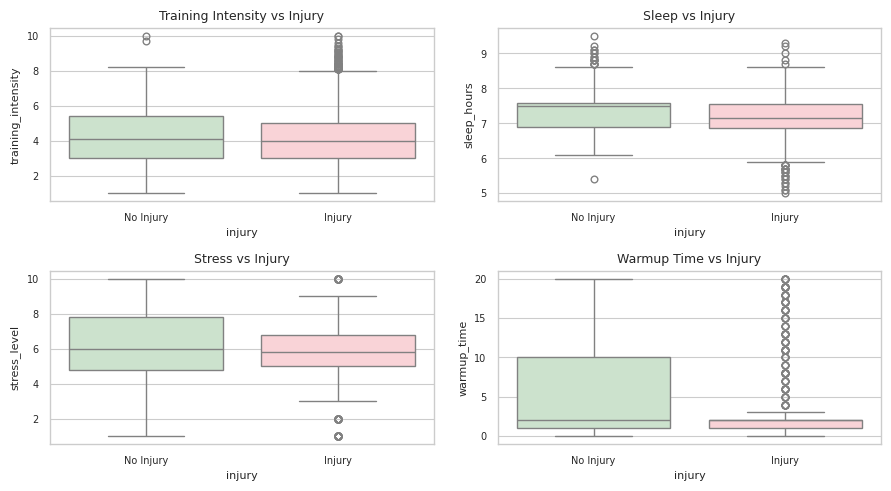

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(9, 5))

palette_binary = {0: "#C8E6C9", 1: "#FFCDD2"}
sns.set(style="whitegrid")
sns.set_context("paper")

plt.rcParams.update({
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

# Training Intensity
sns.boxplot(
    data=df_all,
    x="injury",
    y="training_intensity",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Training Intensity vs Injury")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["No Injury", "Injury"])

# Sleep
sns.boxplot(
    data=df_all,
    x="injury",
    y="sleep_hours",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Sleep vs Injury")
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(["No Injury", "Injury"])

# Stress
sns.boxplot(
    data=df_all,
    x="injury",
    y="stress_level",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Stress vs Injury")
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(["No Injury", "Injury"])

# Warmup
sns.boxplot(
    data=df_all,
    x="injury",
    y="warmup_time",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Warmup Time vs Injury")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["No Injury", "Injury"])

plt.tight_layout()
plt.show()

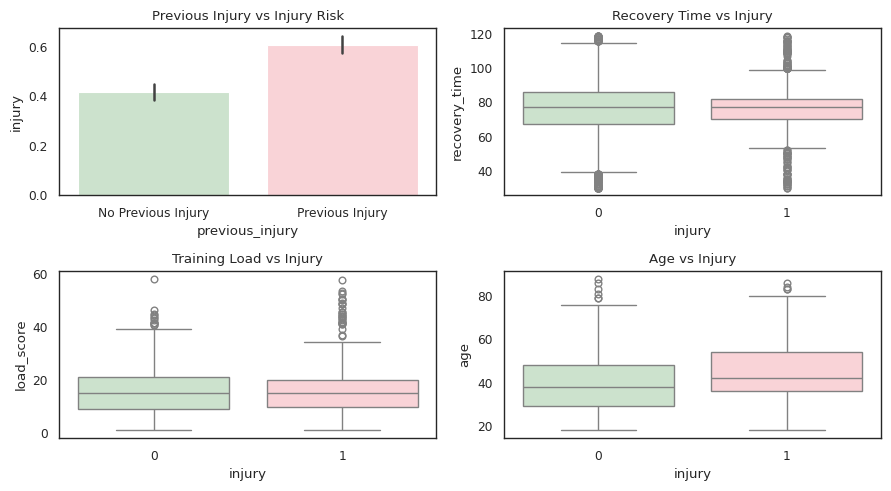

In [28]:
df_all["previous_injury"] = (df_all["previous_injury"] > 0).astype(int)

# Feature Engineering
df_all["load_score"] = df_all["training_intensity"] * df_all["training_frequency"]

fig, axes = plt.subplots(2, 2, figsize=(9, 5))

# 1. Previous Injury
sns.barplot(
    data=df_all,
    x="previous_injury",
    y="injury",
    hue="previous_injury",
    palette=palette_binary,
    legend=False,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Previous Injury vs Injury Risk")
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(["No Previous Injury", "Previous Injury"])

# 2. Recovery Time
sns.boxplot(
    data=df_all,
    x="injury",
    y="recovery_time",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Recovery Time vs Injury")

# 3. Load Score
sns.boxplot(
    data=df_all,
    x="injury",
    y="load_score",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Training Load vs Injury")

# 4. Age
sns.boxplot(
    data=df_all,
    x="injury",
    y="age",
    hue="injury",
    palette=palette_binary,
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Age vs Injury")

plt.tight_layout()
plt.show()

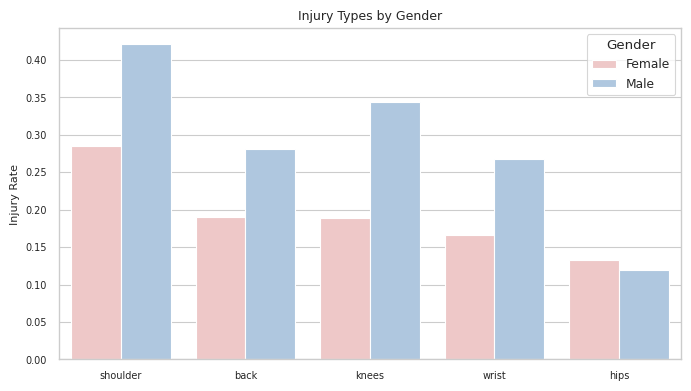

In [24]:
# RAW DATA laden
df_raw = pd.read_sql("SELECT * FROM wl_raw", conn)

# Cleaning
df_raw["gender"] = df_raw["sex"].str.lower()

injury_cols = ["shoulder", "back", "knees", "wrist", "hips"]

mapping = {
    "yes": 1, "no": 0,
    "1": 1, "0": 0
}

for col in injury_cols:
    df_raw[col] = (
        df_raw[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .fillna(0)
        .astype(float)
    )


# Aggregation
injury_types = df_raw.groupby("gender")[injury_cols].mean().reset_index()

injury_types_melted = injury_types.melt(
    id_vars="gender",
    value_vars=injury_cols,
    var_name="injury_type",
    value_name="injury_rate"
)

# Style (wie deine anderen Plots)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
sns.set_context("paper")

plt.rcParams.update({
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7
})

palette_gender = {"m": "#A7C7E7", "f": "#F4C2C2"}

# Plot
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=injury_types_melted,
    x="injury_type",
    y="injury_rate",
    hue="gender",
    palette=palette_gender
)

plt.title("Injury Types by Gender")
plt.xlabel("")
plt.ylabel("Injury Rate")

handles, labels = ax.get_legend_handles_labels()
new_labels = ["Male" if l == "m" else "Female" for l in labels]
ax.legend(handles, new_labels, title="Gender")

plt.tight_layout()
plt.show()

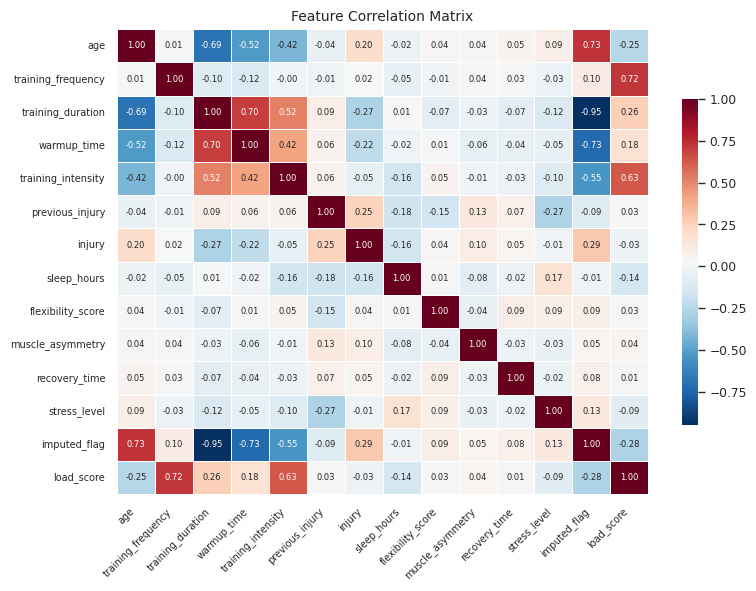

In [26]:
# Korrelation
corr = df_all.select_dtypes(include=["float64", "int64"]).corr()

# Style
sns.set(style="white")
sns.set_context("paper")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    cmap="RdBu_r",          # besser als coolwarm
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.5,
    cbar_kws={"shrink": 0.7}
)

plt.title("Feature Correlation Matrix", fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)

plt.tight_layout()
plt.show()

### Using AI Tools to analyze data

[0 1]
              precision    recall  f1-score   support

           0       0.73      0.47      0.57       153
           1       0.63      0.84      0.72       163

    accuracy                           0.66       316
   macro avg       0.68      0.66      0.65       316
weighted avg       0.68      0.66      0.65       316



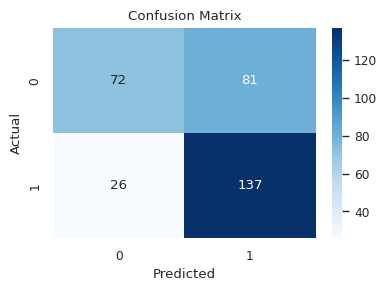

In [34]:
df_model = pd.read_sql("SELECT * FROM athlete_data", conn)

# previous_injury binarisieren
df_model["previous_injury"] = (df_model["previous_injury"] > 0).astype(int)

# gender fix
df_model["gender"] = df_model["gender"].map({"m": 0, "f": 1})

# optional: prüfen
print(df_model["gender"].unique())

# unnötige Spalte entfernen
if "imputed_flag" in df_model.columns:
    df_model = df_model.drop(columns=["imputed_flag"])

X = df_model.drop(columns=["injury"])
y = df_model["injury"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

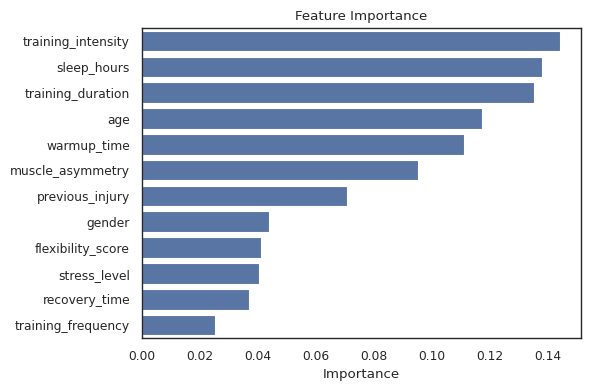

In [35]:
importance = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features).sort_values(ascending=False)

plt.figure(figsize=(6,4))
sns.barplot(x=feat_imp.values, y=feat_imp.index)

plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("")

plt.tight_layout()
plt.show()

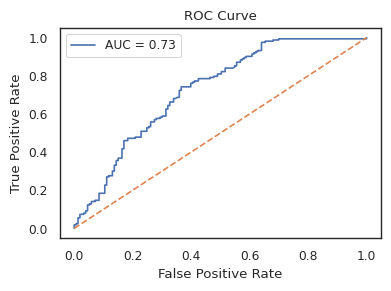

In [40]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4,3))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()